In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


SCBA: nk=50^2, niw=128, T=0.1000, mu=0.0000, v=0.050  [numpy.fft]
Converged at step    4  diff=3.636e-11  mu=-0.314818


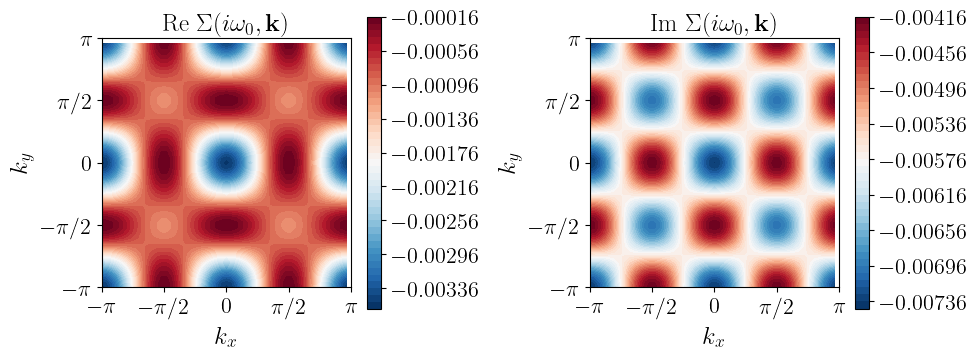

In [ ]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 50
bz = BZ(lat, nk=nk)

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, bz, niw)
scba.run(0.05, beta, n, ibz=True)

S_iwk = bz.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1367: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/numpy/ma/core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


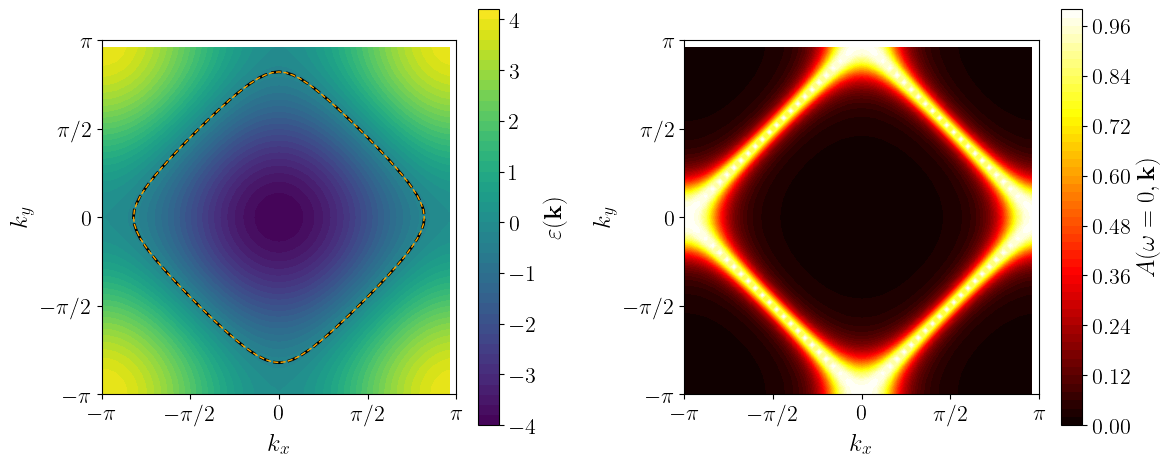

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

lat = LATTICE(dim=2)
bz = BZ(lat, nk=nk, ibz=False)

e_k = bz.e_k.reshape(nk,nk)
Sk0_real = S_iwk[0].reshape(nk,nk)

kx = bz.k_vecs[:,0].reshape(nk,nk)
ky = bz.k_vecs[:,1].reshape(nk,nk)
kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)
Sk0_real = np.roll(np.roll(Sk0_real, nk//2, axis=0), nk//2, axis=1)

G_k_n0 = 1.0 / (1j * np.pi / beta - e_k - Sk0_real)
A_k0 = -G_k_n0.imag / np.pi

cf = axs[0].contourf(kx, ky, e_k - Sk0_real, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')

mu = get_mu(e_k=bz.e_k, n_goal=0.85, beta=1/0.1)
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)
axs[0].contour(kx, ky, e_k - Sk0_real, levels=[mu], colors='orange', linewidths=1)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

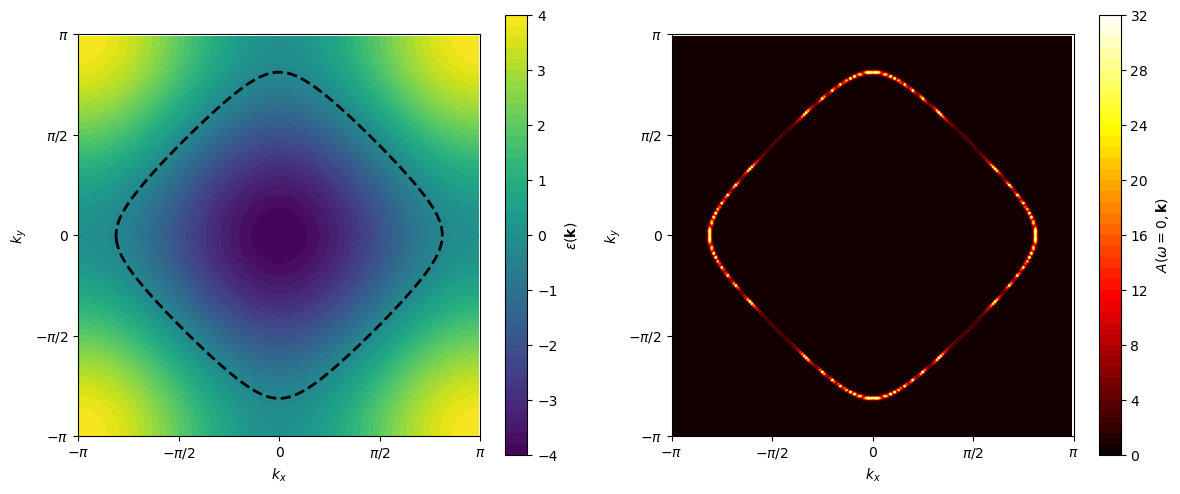

In [ ]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


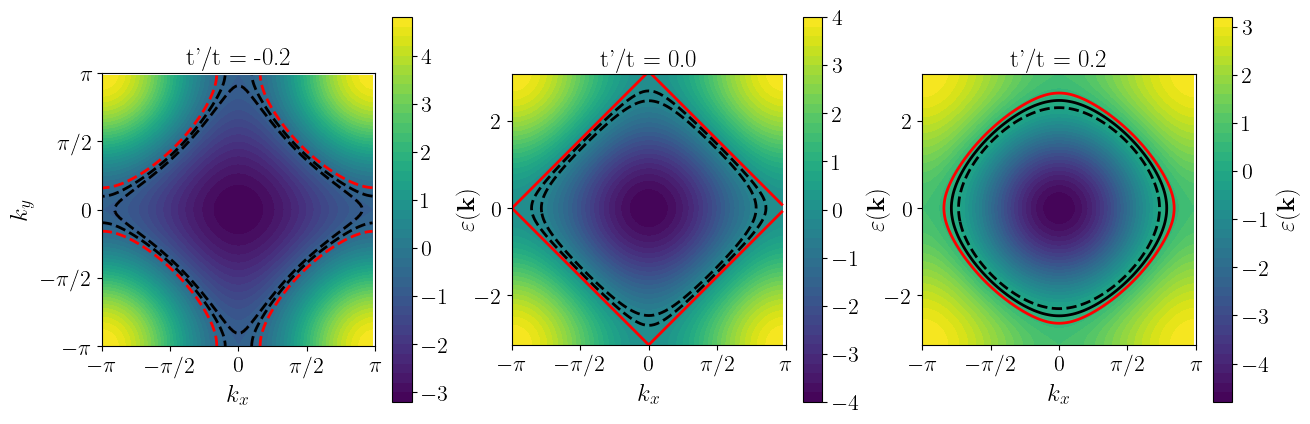

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

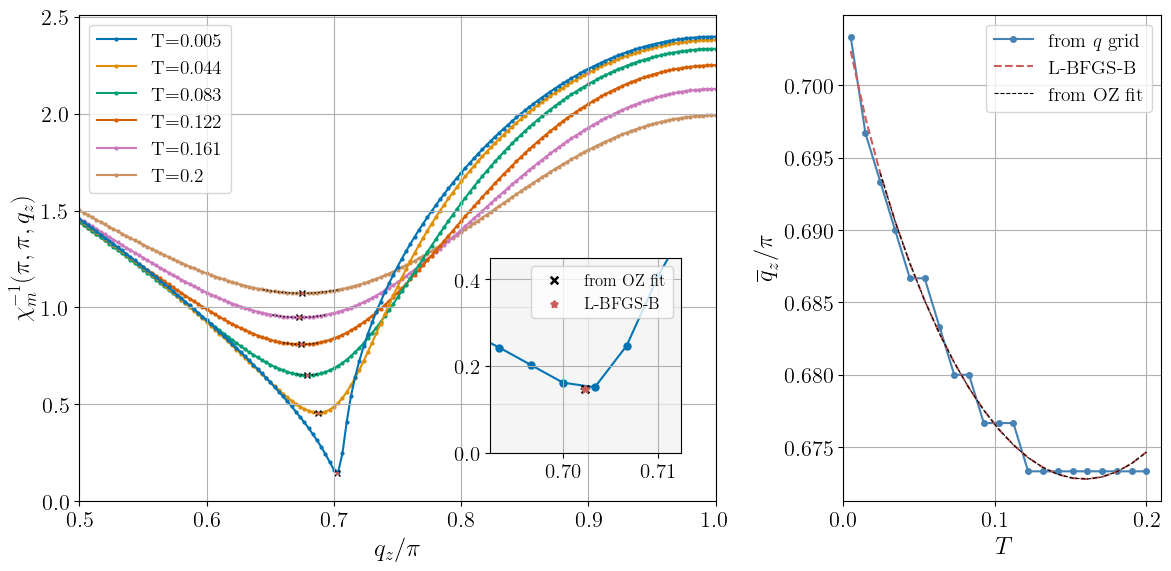

In [ ]:
n = 0.745
U = 3

with HDFArchive(f"data/chimin/G0tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

print(data['OZ_fit'])
plot_chimin(data, peak_on_the='left')
plt.show()

[[ 1.33463627e-02 -2.22910426e+01  1.28530071e-02  7.94470165e-01]
 [ 3.99317809e-02 -9.82052607e+00  3.93314157e-02  7.97901809e-01]
 [ 6.77961238e-02 -6.18190512e+00  6.61241145e-02  8.01759016e-01]
 [ 9.68385357e-02 -4.24546282e+00  9.29420069e-02  8.05535140e-01]
 [ 1.25725370e-01 -3.02461767e+00  1.19248235e-01  8.09059264e-01]
 [ 1.53294526e-01 -2.17823057e+00  1.44677028e-01  8.12257026e-01]
 [ 1.79301991e-01 -1.57387843e+00  1.69237773e-01  8.15123563e-01]
 [ 2.04415695e-01 -1.15018948e+00  1.93272064e-01  8.17721154e-01]
 [ 2.29712332e-01 -8.65746648e-01  2.17246092e-01  8.20153379e-01]
 [ 2.56277057e-01 -6.86613635e-01  2.41596478e-01  8.22536251e-01]
 [ 2.85079338e-01 -5.85588969e-01  2.66686940e-01  8.24980820e-01]
 [ 3.17020865e-01 -5.42241568e-01  2.92831737e-01  8.27586856e-01]
 [ 3.53045963e-01 -5.42076638e-01  3.20340486e-01  8.30442728e-01]
 [ 3.94253405e-01 -5.75334952e-01  3.49556897e-01  8.33627878e-01]
 [ 4.41203511e-01 -6.35642598e-01  3.80539020e-01  8.37215721e

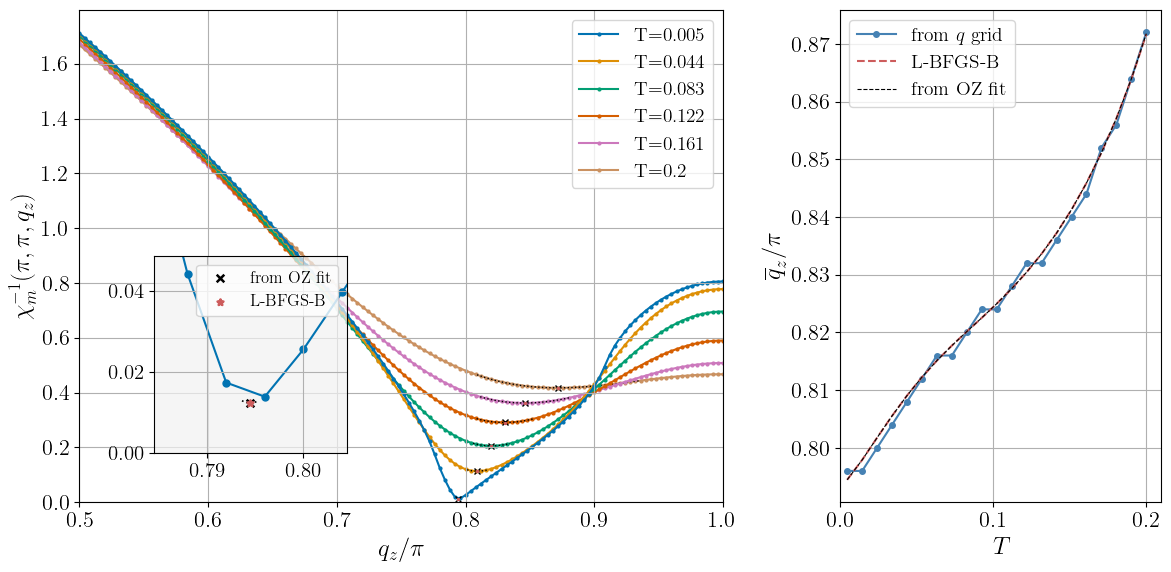

In [13]:
n = 0.8485
U = 3
tp = 0.1

with HDFArchive(f"data/chimin/G0tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

print(data['OZ_fit'])
plot_chimin(data, peak_on_the='right')
plt.show()

[[ 2.72237518e-01  1.68526542e-08  9.65869838e-03  1.00000000e+00]
 [ 2.41709588e-01  4.23718732e-07  2.25445808e-02  1.00000000e+00]
 [ 2.29551907e-01  4.86453481e-08  3.71762051e-02  1.00000000e+00]
 [ 2.56681772e-01 -6.33003915e-08  5.34276898e-02  1.00000000e+00]
 [ 3.12537341e-01 -1.57626964e-07  7.08465061e-02  1.00000000e+00]
 [ 3.92893310e-01 -4.23571698e-08  8.89716287e-02  1.00000000e+00]
 [ 4.96208116e-01 -1.13832211e-07  1.07311333e-01  1.00000000e+00]
 [ 6.33606212e-01 -1.98790280e-07  1.26901809e-01  1.00000000e+00]
 [ 7.79665289e-01 -4.96894917e-08  1.44998191e-01  1.00000000e+00]
 [ 9.25917389e-01 -3.03128817e-08  1.61666609e-01  1.00000000e+00]
 [ 1.05320843e+00 -9.77656015e-08  1.76419315e-01  1.00000000e+00]
 [ 1.14857279e+00 -5.61472429e-08  1.89531547e-01  1.00000000e+00]
 [ 1.21059177e+00  1.60730159e-08  2.01981782e-01  1.00000000e+00]
 [ 1.23066996e+00 -2.48197072e-08  2.13418065e-01  1.00000000e+00]
 [ 1.25272470e+00  1.09975377e-08  2.28044504e-01  1.00000000e

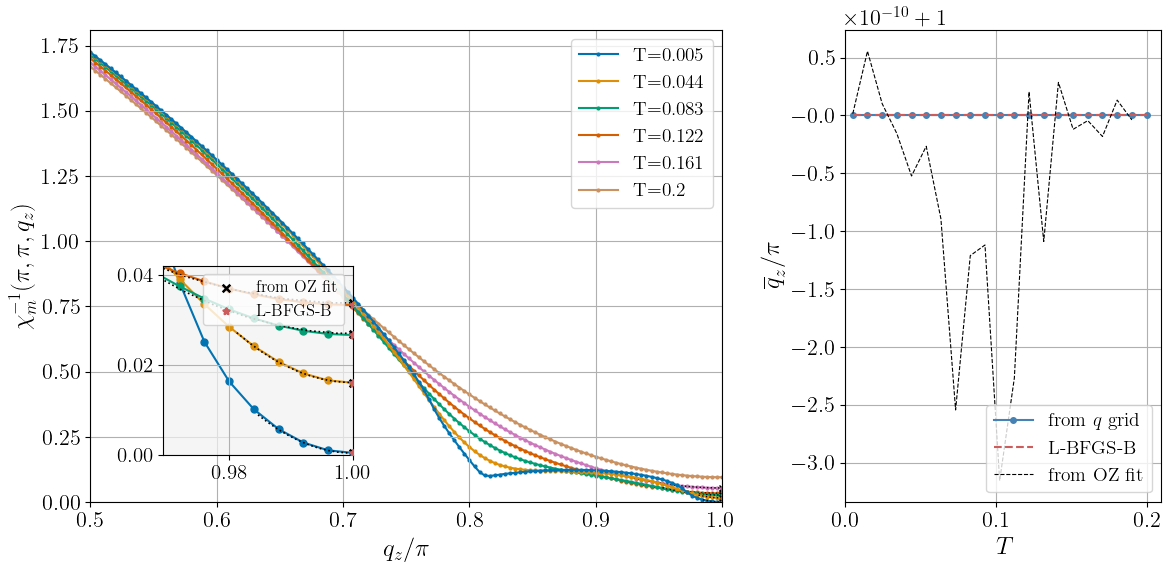

In [11]:
n = 0.88493
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/chimin/G0tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}
    
print(data['OZ_fit'])
plot_chimin(data, peak_on_the='right')
plt.show()

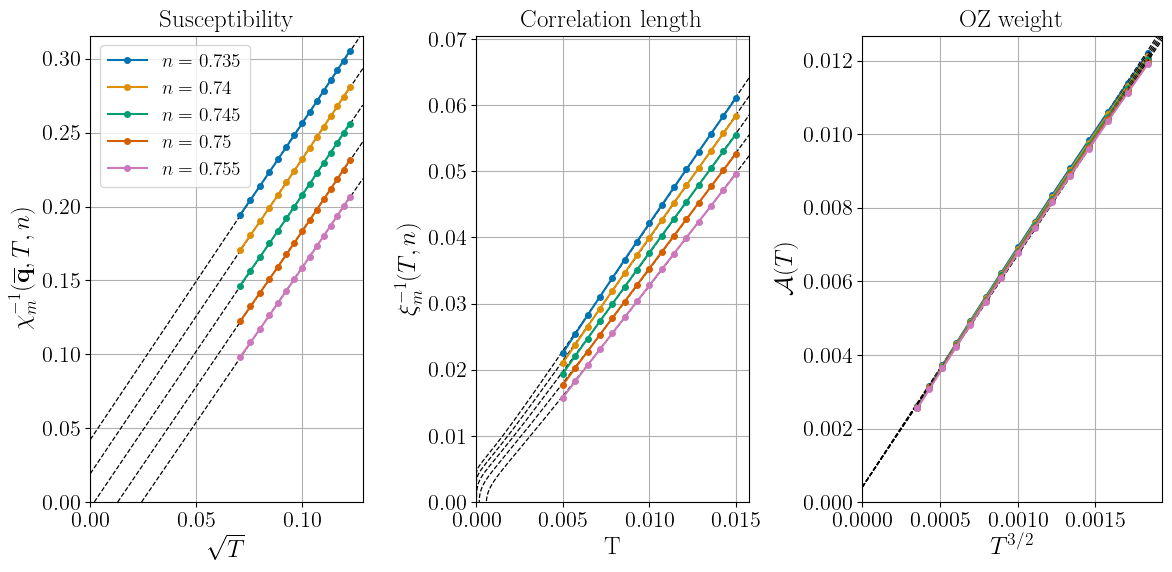

In [4]:
U = 3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1., 1.5), fit=True, right='OZ')
plt.show()

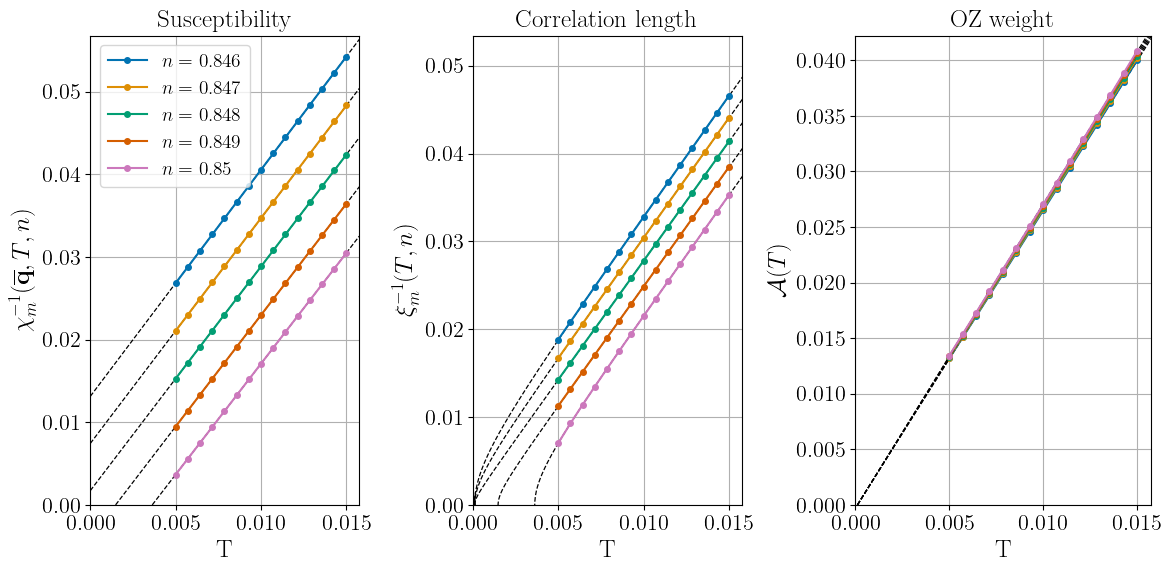

In [12]:
U = 3
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1., 1., 1.), fit=True, right='OZ')
plt.show()

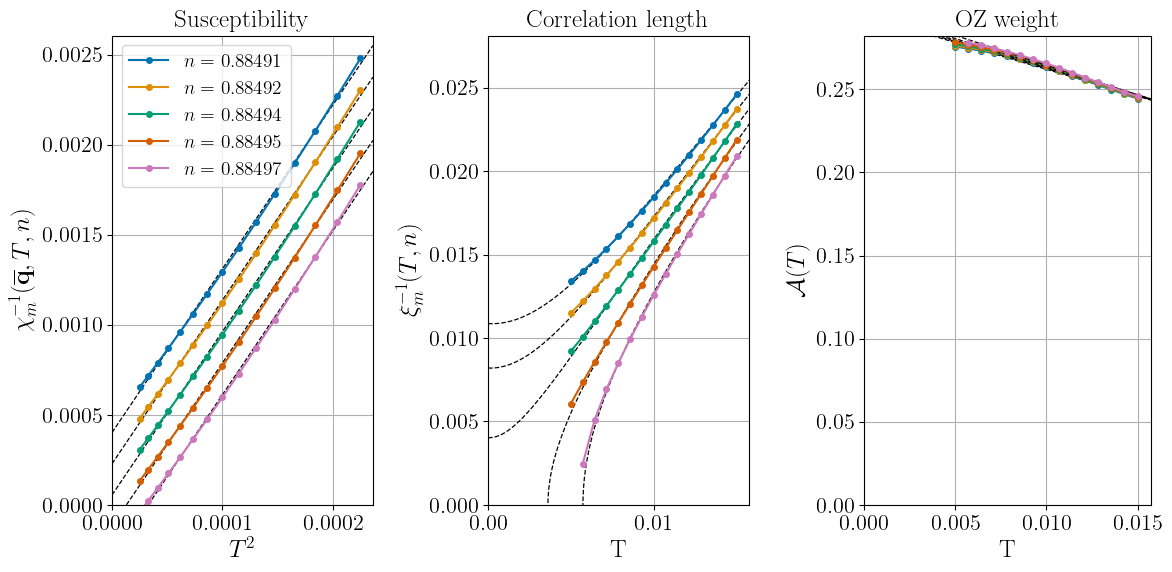

In [3]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2, 1, 1.), fit=True, right='OZ')
plt.show()

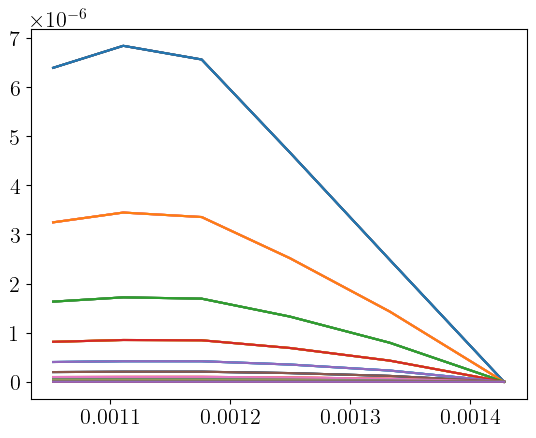

In [4]:
U = 3
tp = 0.2

data_list = []
nk_list = np.arange(700, 1000, 50)
for nk in nk_list:
    with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}nk{nk}.h5", "r") as ar:
        data = {k: ar[k] for k in ar}
    data_list.append(data)

for n in range(5):
    invchi_min = np.array([data['invchi_min'][0,:] for data in data_list])

    plt.plot(1/nk_list, invchi_min - invchi_min[0])
plt.show()

/home/carlo/Desktop/qc/scripts/plot.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


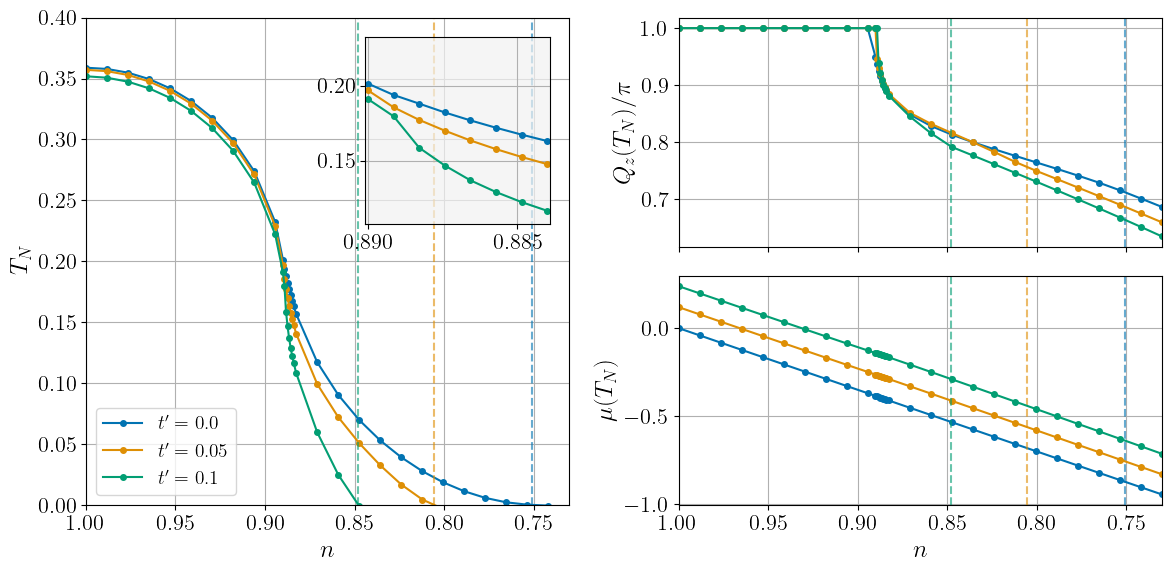

/home/carlo/Desktop/qc/scripts/plot.py:343: RuntimeWarning: overflow encountered in power
  y2 = -abs(data['cOZ']/data['aOZ'])**(1/data['bOZ']) * np.sign(data['cOZ']/data['aOZ'])


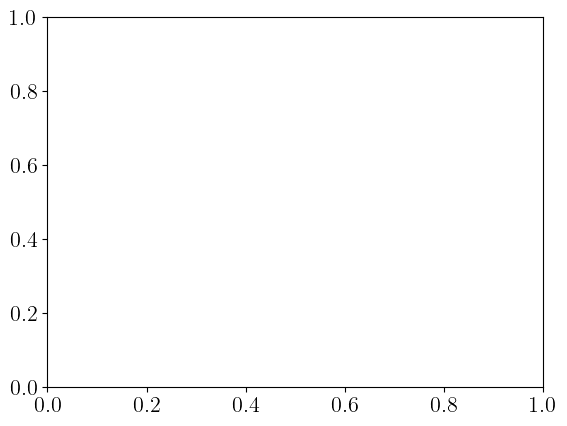

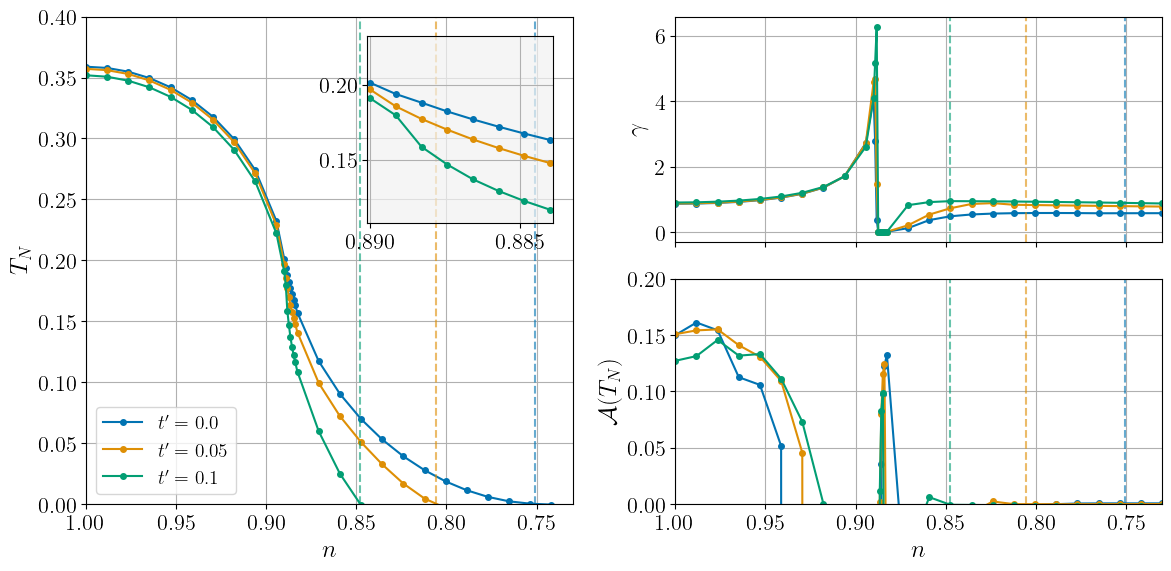

In [90]:
U = 3
tp_list = [0., 0.05, 0.1]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='commens')
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='scaling')
plt.show()

/home/carlo/Desktop/qc/scripts/plot.py:386: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


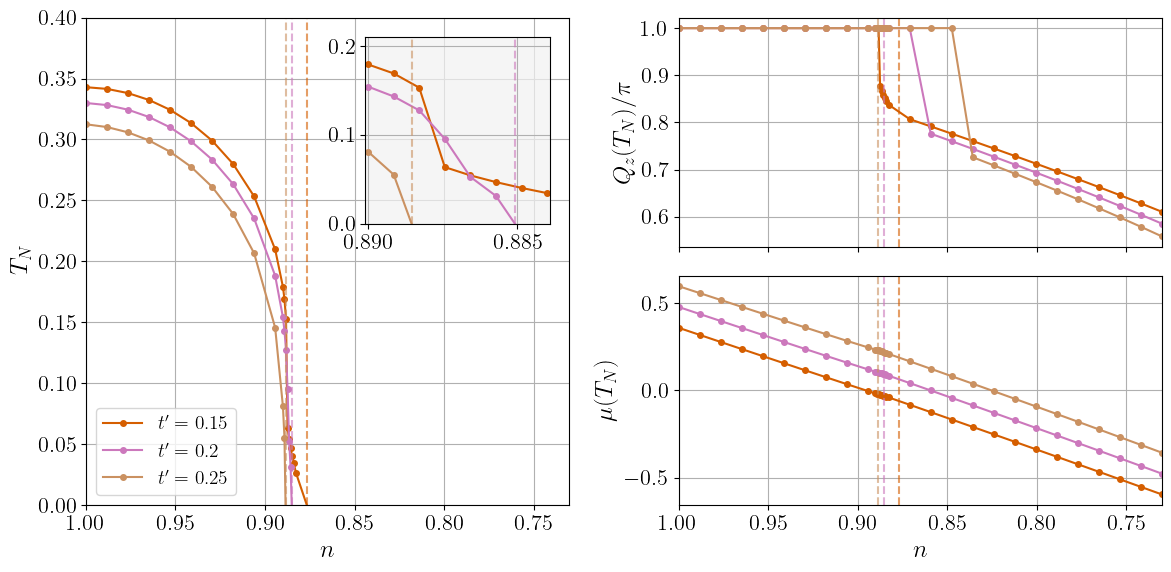

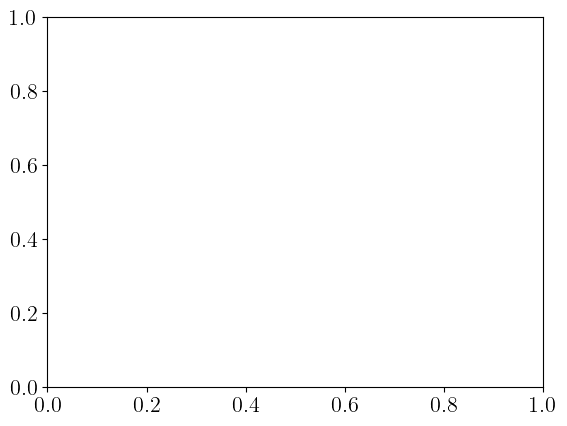

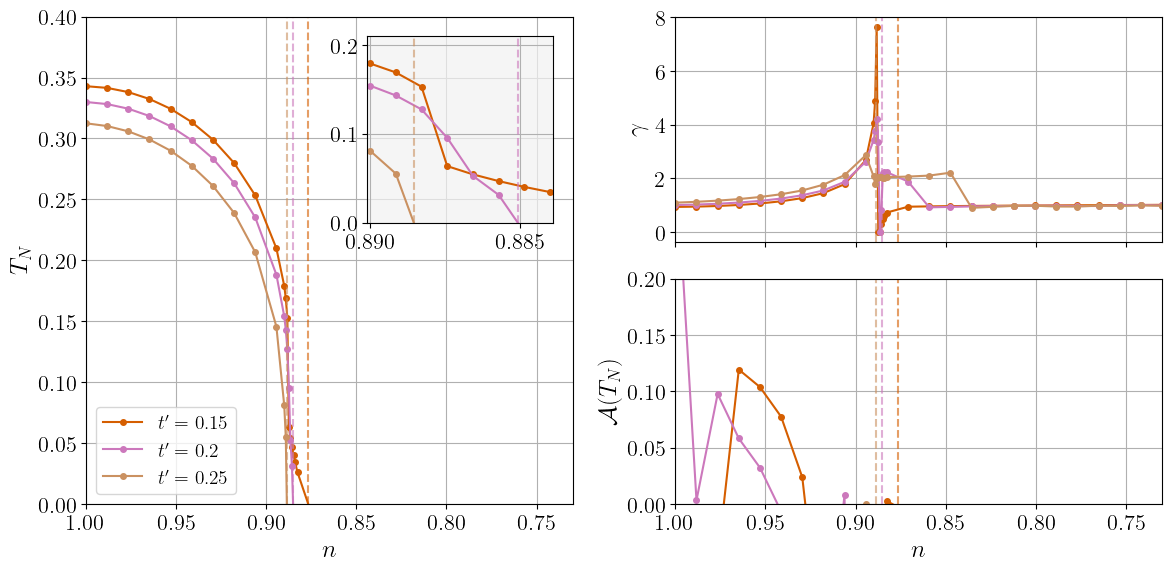

In [5]:
U = 3
tp_list = [0.15, 0.2, 0.25]

data_list = []
for tp in tp_list:
    with HDFArchive(f"data/diagram/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
        data_list.append({k: ar[k] for k in ar})

plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='commens', c0=3)
plt.show()

plt.cla()
plot_diagram(data_list, tp_list, "t'", inset_xrange=[0.8839, 0.8901], subplots='scaling', c0=3)
plt.show()